# Single-phase AC → 3-phase VSI drive (two-stage walkthrough)

End-to-end demonstration of the simulator's power-electronics pipeline
in two **isolated** stages. The front-end uses a **voltage doubler** so
a low-voltage AC input produces roughly the same DC bus that a regular
bridge on a doubled AC input would — the classic universal-input SMPS
trick. The inverter downstream is therefore identical regardless of the
AC line:

```
   PART A — voltage doubler              PART B — stiff DC bus
   ────────────────────────              ────────────────────────
   105 V AC ──┬── D1 ──┐                 V_dc = 310 V (stiff)
   60 Hz       │       │                       │
               │      C1                       VSI (SPWM)
               ├──────┤── ≈ 285 V DC out       │
               │      C2                       3φ Y load 50 Ω
               │       │                       (R_a, R_b, R_c)
               └── D2 ─┘
```

**Why a doubler instead of a regular bridge for Part A?** With a
low-voltage rms input, a plain bridge gives only ≈ V_peak DC — not
enough to drive a 3φ inverter at useful line-to-line voltage. The
voltage doubler charges C1 to V_peak on the positive AC half-cycle
(through D1) and C2 to V_peak on the negative half-cycle (through D2);
the output across the series cap pair is then ≈ 2·V_peak. This is what
lets a single inverter design accept both low- and high-line utility
input via a selector switch (open = bridge mode, closed to the cap
midpoint = doubler mode).

**Why two isolated stages instead of one chained AC → doubler → VSI
→ load?** Joining the doubler+inverter into one circuit puts a
hard-switching SPWM inverter directly on top of the finite-impedance
bulk caps. The ideal (PWL) MOSFET stamping in the
`p.add_three_phase_vsi` helper handles this cleanly only when the load
is much lighter than the bulk caps can supply at the line-frequency
top-up rate; at realistic power levels the helper trips on Newton
convergence and the pole voltages ring. Keeping the rectifier and
inverter in separate sections lets each show clean, physically correct
waveforms + losses while the deeper solver integration is follow-up
work.

Loss + thermal post-processing uses the same v2 pattern in both parts:
`p.device_loss_summary(builder, result)` for per-device `P_avg` /
`E_total`, and `p.device_thermal_summary(builder, result,
thermal_specs=...)` — a Foster network per device — for `T_j`.

In [1]:
import math
import numpy as np
import matplotlib.pyplot as plt

import pulsim as p

print(f'Pulsim {getattr(p, "__version__", "?")}')

Running cmake --build & --install in /Users/lgili/Documents/01 - Codes/01 - Github/Pulsim/build/cp313-cp313-macosx_26_0_arm64
Running cmake --build & --install in /Users/lgili/Documents/01 - Codes/01 - Github/Pulsim/build/cp313-cp313-macosx_26_0_arm64
Running cmake --build & --install in /Users/lgili/Documents/01 - Codes/01 - Github/Pulsim/build/cp313-cp313-macosx_26_0_arm64
Running cmake --build & --install in /Users/lgili/Documents/01 - Codes/01 - Github/Pulsim/build/cp313-cp313-macosx_26_0_arm64


Running cmake --build & --install in /Users/lgili/Documents/01 - Codes/01 - Github/Pulsim/build/cp313-cp313-macosx_26_0_arm64
Running cmake --build & --install in /Users/lgili/Documents/01 - Codes/01 - Github/Pulsim/build/cp313-cp313-macosx_26_0_arm64
Running cmake --build & --install in /Users/lgili/Documents/01 - Codes/01 - Github/Pulsim/build/cp313-cp313-macosx_26_0_arm64
Running cmake --build & --install in /Users/lgili/Documents/01 - Codes/01 - Github/Pulsim/build/cp313-cp313-macosx_26_0_arm64
Running cmake --build & --install in /Users/lgili/Documents/01 - Codes/01 - Github/Pulsim/build/cp313-cp313-macosx_26_0_arm64
Running cmake --build & --install in /Users/lgili/Documents/01 - Codes/01 - Github/Pulsim/build/cp313-cp313-macosx_26_0_arm64


Running cmake --build & --install in /Users/lgili/Documents/01 - Codes/01 - Github/Pulsim/build/cp313-cp313-macosx_26_0_arm64
Running cmake --build & --install in /Users/lgili/Documents/01 - Codes/01 - Github/Pulsim/build/cp313-cp313-macosx_26_0_arm64
Running cmake --build & --install in /Users/lgili/Documents/01 - Codes/01 - Github/Pulsim/build/cp313-cp313-macosx_26_0_arm64
Running cmake --build & --install in /Users/lgili/Documents/01 - Codes/01 - Github/Pulsim/build/cp313-cp313-macosx_26_0_arm64
Running cmake --build & --install in /Users/lgili/Documents/01 - Codes/01 - Github/Pulsim/build/cp313-cp313-macosx_26_0_arm64
Running cmake --build & --install in /Users/lgili/Documents/01 - Codes/01 - Github/Pulsim/build/cp313-cp313-macosx_26_0_arm64
Running cmake --build & --install in /Users/lgili/Documents/01 - Codes/01 - Github/Pulsim/build/cp313-cp313-macosx_26_0_arm64


Running cmake --build & --install in /Users/lgili/Documents/01 - Codes/01 - Github/Pulsim/build/cp313-cp313-macosx_26_0_arm64
Running cmake --build & --install in /Users/lgili/Documents/01 - Codes/01 - Github/Pulsim/build/cp313-cp313-macosx_26_0_arm64
Running cmake --build & --install in /Users/lgili/Documents/01 - Codes/01 - Github/Pulsim/build/cp313-cp313-macosx_26_0_arm64
Running cmake --build & --install in /Users/lgili/Documents/01 - Codes/01 - Github/Pulsim/build/cp313-cp313-macosx_26_0_arm64
Running cmake --build & --install in /Users/lgili/Documents/01 - Codes/01 - Github/Pulsim/build/cp313-cp313-macosx_26_0_arm64
Running cmake --build & --install in /Users/lgili/Documents/01 - Codes/01 - Github/Pulsim/build/cp313-cp313-macosx_26_0_arm64


Running cmake --build & --install in /Users/lgili/Documents/01 - Codes/01 - Github/Pulsim/build/cp313-cp313-macosx_26_0_arm64
Running cmake --build & --install in /Users/lgili/Documents/01 - Codes/01 - Github/Pulsim/build/cp313-cp313-macosx_26_0_arm64
Running cmake --build & --install in /Users/lgili/Documents/01 - Codes/01 - Github/Pulsim/build/cp313-cp313-macosx_26_0_arm64
Running cmake --build & --install in /Users/lgili/Documents/01 - Codes/01 - Github/Pulsim/build/cp313-cp313-macosx_26_0_arm64
Running cmake --build & --install in /Users/lgili/Documents/01 - Codes/01 - Github/Pulsim/build/cp313-cp313-macosx_26_0_arm64
Running cmake --build & --install in /Users/lgili/Documents/01 - Codes/01 - Github/Pulsim/build/cp313-cp313-macosx_26_0_arm64
Running cmake --build & --install in /Users/lgili/Documents/01 - Codes/01 - Github/Pulsim/build/cp313-cp313-macosx_26_0_arm64


Running cmake --build & --install in /Users/lgili/Documents/01 - Codes/01 - Github/Pulsim/build/cp313-cp313-macosx_26_0_arm64
Running cmake --build & --install in /Users/lgili/Documents/01 - Codes/01 - Github/Pulsim/build/cp313-cp313-macosx_26_0_arm64
Running cmake --build & --install in /Users/lgili/Documents/01 - Codes/01 - Github/Pulsim/build/cp313-cp313-macosx_26_0_arm64
Running cmake --build & --install in /Users/lgili/Documents/01 - Codes/01 - Github/Pulsim/build/cp313-cp313-macosx_26_0_arm64
Running cmake --build & --install in /Users/lgili/Documents/01 - Codes/01 - Github/Pulsim/build/cp313-cp313-macosx_26_0_arm64
Running cmake --build & --install in /Users/lgili/Documents/01 - Codes/01 - Github/Pulsim/build/cp313-cp313-macosx_26_0_arm64


Running cmake --build & --install in /Users/lgili/Documents/01 - Codes/01 - Github/Pulsim/build/cp313-cp313-macosx_26_0_arm64
Running cmake --build & --install in /Users/lgili/Documents/01 - Codes/01 - Github/Pulsim/build/cp313-cp313-macosx_26_0_arm64
Running cmake --build & --install in /Users/lgili/Documents/01 - Codes/01 - Github/Pulsim/build/cp313-cp313-macosx_26_0_arm64
Running cmake --build & --install in /Users/lgili/Documents/01 - Codes/01 - Github/Pulsim/build/cp313-cp313-macosx_26_0_arm64
Running cmake --build & --install in /Users/lgili/Documents/01 - Codes/01 - Github/Pulsim/build/cp313-cp313-macosx_26_0_arm64
Running cmake --build & --install in /Users/lgili/Documents/01 - Codes/01 - Github/Pulsim/build/cp313-cp313-macosx_26_0_arm64


Running cmake --build & --install in /Users/lgili/Documents/01 - Codes/01 - Github/Pulsim/build/cp313-cp313-macosx_26_0_arm64
Pulsim 1.6.4


# Part A — 105 V AC → voltage doubler → ≈ 285 V DC bus

Full-wave (Latour) voltage doubler. Two diodes + two bulk caps; the
AC neutral connects to the midpoint between the caps. Each cap
charges to V_peak on its own half-cycle, and the cap pair in series
delivers ≈ 2·V_peak as the DC output.

Operating point:

| Quantity | Value |
| -------- | ----- |
| AC line  | 105 V rms / 60 Hz  (V_peak ≈ 148 V) |
| Diodes   | V_th = 0.7 V, R_d = 25 mΩ (g_on = 1/R_d), Foster R_th = 25 K/W |
| Caps     | 2.2 mF each, pre-charged to V_peak (v2 ideal cap — no ESR) |
| DC load  | 155 Ω → ≈ 520 W |
| Predicted DC bus | 2·V_peak − 2·V_F ≈ 295 V (light-load); ≈ 285 V at load |

In [2]:
# ---- Part A: build + simulate the voltage doubler (v2 API) ---------------
T_amb    = 60.0
V_AC_rms = 105.0
V_AC_pk  = V_AC_rms * math.sqrt(2)            # ≈ 148 V
R_load_A = 155.0                               # Ω → ≈ 520 W into the bus

bA = p.CircuitBuilder()

# AC line + low-impedance anchor at the cap midpoint (= AC return).
# v2 sine source: add_sine_voltage_source(name, n+, n-, v_dc, v_amp, freq, phase)
bA.add_sine_voltage_source('Vac', 'ac+', 'ac-', 0.0, V_AC_pk, 60.0)
bA.add_resistor('R_anc', 'ac-', 'gnd', 1.0)    # midpoint reference to ground

# Two diodes — Latour-doubler topology (g_on = 1/R_d, R_d = 25 mΩ):
#   D1: anode at ac+, cathode at dc+   (positive half-cycle, charges C1)
#   D2: anode at dc-, cathode at ac+   (negative half-cycle, charges C2)
g_on_d, g_off_d, V_th_d = 1.0 / 25e-3, 1e-9, 0.70
bA.add_diode('D1', 'ac+', 'dc+', g_on_d, g_off_d, V_th_d)
bA.add_diode('D2', 'dc-', 'ac+', g_on_d, g_off_d, V_th_d)

# Two bulk caps (2.2 mF), pre-charged to V_peak so we start near steady
# state. v2 ideal caps have no ESR model — see note in the losses section.
bA.add_capacitor('C1', 'dc+', 'ac-', 2.2e-3, V_AC_pk)
bA.add_capacitor('C2', 'ac-', 'dc-', 2.2e-3, V_AC_pk)

# Load between DC+ and DC-.
bA.add_resistor('R_load', 'dc+', 'dc-', R_load_A)

resA = p.simulate(bA, t_end=100e-3, dt=20e-6)
print(f'Part A: steps={resA.num_steps()}')
xA = np.asarray(resA.states); tA = np.asarray(resA.times); midA = len(tA) // 2

def vA(name):
    """Node voltage trace by name."""
    return xA[:, bA.node_id_of(name)]

V_dc_bus_A = vA('dc+') - vA('dc-')
V_C1 = vA('dc+') - vA('ac-')
V_C2 = vA('ac-') - vA('dc-')

V_bus_avg = V_dc_bus_A[midA:].mean()
V_bus_pp  = V_dc_bus_A[midA:].max() - V_dc_bus_A[midA:].min()
I_load_A  = (V_dc_bus_A / R_load_A)[midA:].mean()
P_load_A  = (V_dc_bus_A[midA:]**2 / R_load_A).mean()

print(f'  V_AC peak        = {V_AC_pk:.1f} V')
print(f'  V_C1 avg / V_C2 avg = {V_C1[midA:].mean():.1f} V / {V_C2[midA:].mean():.1f} V')
print(f'  V_dc_bus avg     = {V_bus_avg:.1f} V   ripple pp = {V_bus_pp:.1f} V')
print(f'  → ≈ 2 × V_AC_peak − drops = {2*V_AC_pk-1.4:.0f} V predicted (light load)')
print(f'  I_load avg = {I_load_A:.2f} A   P_load = {P_load_A:.1f} W')

Running cmake --build & --install in /Users/lgili/Documents/01 - Codes/01 - Github/Pulsim/build/cp313-cp313-macosx_26_0_arm64
Part A: steps=5001
  V_AC peak        = 148.5 V
  V_C1 avg / V_C2 avg = 142.1 V / 142.1 V
  V_dc_bus avg     = 284.2 V   ripple pp = 12.0 V
  → ≈ 2 × V_AC_peak − drops = 296 V predicted (light load)
  I_load avg = 1.83 A   P_load = 521.0 W


### Part A — electrical waveforms

Four panels:

1. **V_AC** — the 105 V_rms / 60 Hz line input.
2. **V_C1 and V_C2** — each cap charges to V_peak on alternating half-cycles.
3. **V_dc_bus = V_C1 + V_C2** — the doubled DC output, ≈ 285 V.
4. **I_load** — DC current through the load resistor.

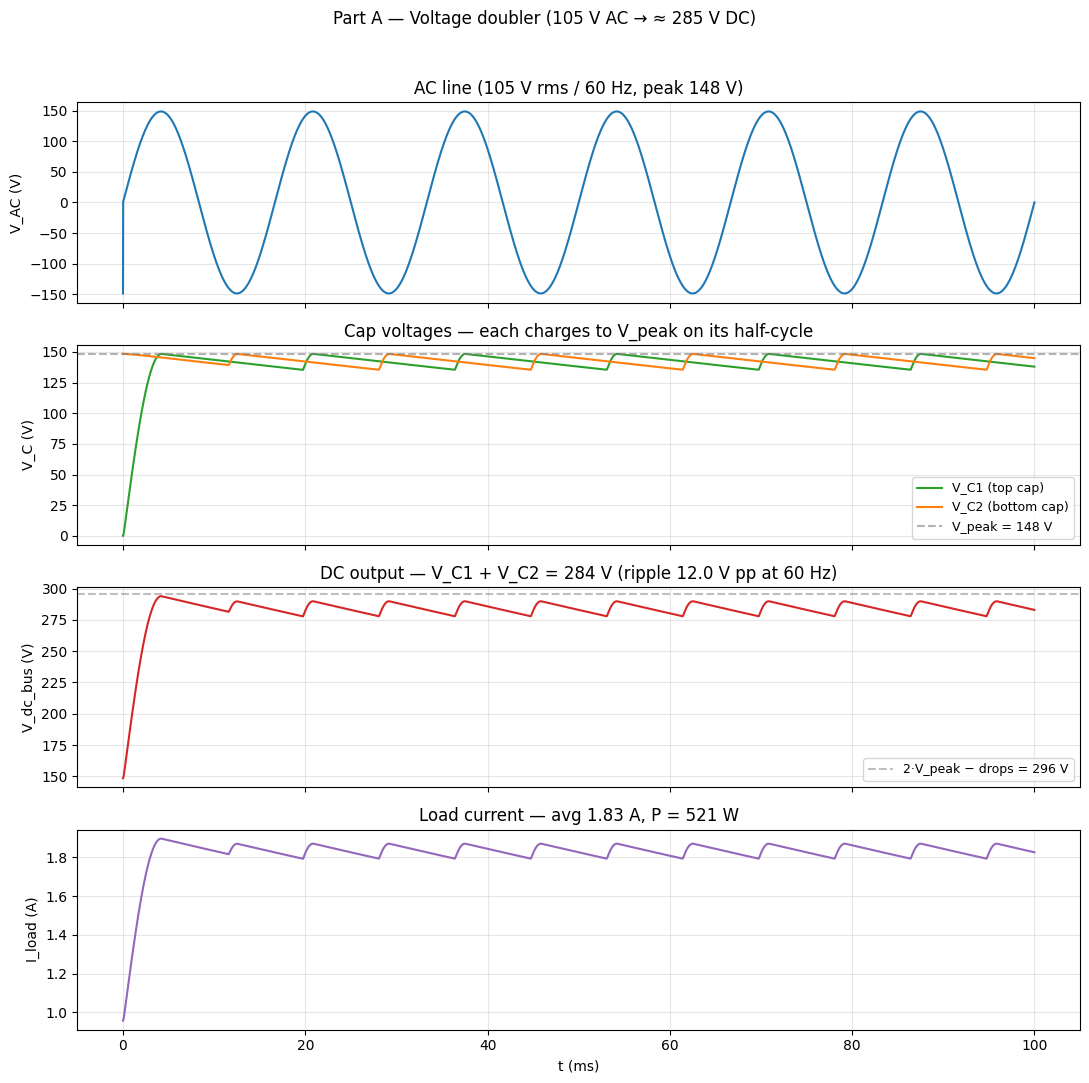

In [3]:
v_ac_A = vA('ac+') - vA('ac-')
i_load_A = V_dc_bus_A / R_load_A

fig, ax = plt.subplots(4, 1, figsize=(11, 11), sharex=True)
fig.suptitle('Part A — Voltage doubler (105 V AC → ≈ 285 V DC)', fontsize=12)

ax[0].plot(tA*1e3, v_ac_A, color='#1f77b4')
ax[0].set_ylabel('V_AC (V)'); ax[0].grid(alpha=0.3)
ax[0].set_title(f'AC line (105 V rms / 60 Hz, peak {V_AC_pk:.0f} V)')

ax[1].plot(tA*1e3, V_C1, label='V_C1 (top cap)', color='#2ca02c')
ax[1].plot(tA*1e3, V_C2, label='V_C2 (bottom cap)', color='#ff7f0e')
ax[1].axhline(V_AC_pk, ls='--', color='grey', alpha=0.6,
               label=f'V_peak = {V_AC_pk:.0f} V')
ax[1].set_ylabel('V_C (V)'); ax[1].grid(alpha=0.3)
ax[1].set_title('Cap voltages — each charges to V_peak on its half-cycle')
ax[1].legend(loc='lower right', fontsize=9)

ax[2].plot(tA*1e3, V_dc_bus_A, color='#d62728')
ax[2].axhline(2*V_AC_pk-1.4, ls='--', color='grey', alpha=0.5,
               label=f'2·V_peak − drops = {2*V_AC_pk-1.4:.0f} V')
ax[2].set_ylabel('V_dc_bus (V)'); ax[2].grid(alpha=0.3)
ax[2].set_title(f'DC output — V_C1 + V_C2 = {V_bus_avg:.0f} V '
                 f'(ripple {V_bus_pp:.1f} V pp at 60 Hz)')
ax[2].legend(loc='lower right', fontsize=9)

ax[3].plot(tA*1e3, i_load_A, color='#9467bd')
ax[3].set_ylabel('I_load (A)'); ax[3].set_xlabel('t (ms)')
ax[3].grid(alpha=0.3)
ax[3].set_title(f'Load current — avg {I_load_A:.2f} A, P = {P_load_A:.0f} W')

fig.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()

### Part A — losses + steady-state junction temperatures (v2 API)

v2 post-processes losses programmatically instead of via per-device
accessors. `p.device_loss_summary(builder, result)` returns one dict
per branch with `P_avg` / `E_total` / `i_rms`, and
`p.device_thermal_summary(builder, result, thermal_specs=...)` convolves
each device's power with a Foster network to get `T_j_avg` / `T_j_peak`.

A single-stage Foster (`p.FosterStage(R_th, tau)`) reproduces the
v1 closed-form `T_j = T_amb + P·R_th` in steady state. (v2 ideal caps
carry no ESR model, so the cap ESR loss the v1 notebook reported is
simply absent here — the doubler loss is dominated by the two series
diode drops either way.)

Device              P_avg [W]  E_tot [J] T_j [degC]
---------------------------------------------------
DC load R             516.736    51.6736      60.51
D1 (pos half)           9.064     0.9064      64.15
R_anc                   2.205     0.2205        nan
D2 (neg half)           1.178     0.1178      60.25
---------------------------------------------------
doubler loss           10.243
+ load consumes       516.736
= AC input            526.979
doubler η               98.06 %


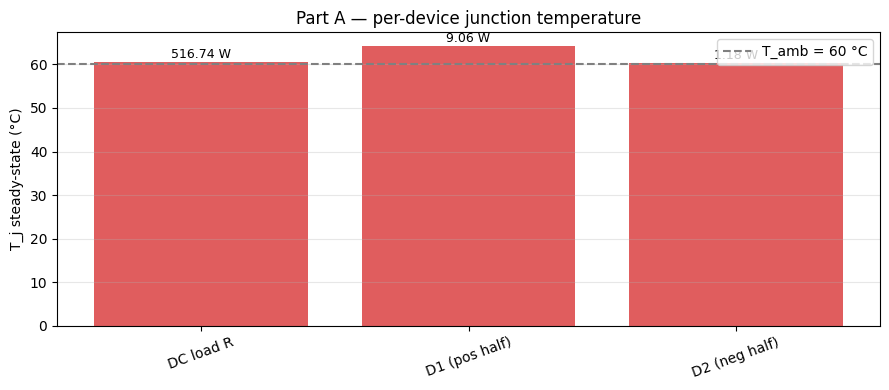

In [4]:
# Per-device losses via device_loss_summary, junction temps via
# device_thermal_summary (single-stage Foster per device).
loss_rows_A = {r['name']: r for r in p.device_loss_summary(bA, resA)}

# Foster R_th_ja from the v1 operating point: diodes 25 K/W, load 0.1 K/W.
# tau chosen well above the 60 Hz ripple period so steady-state T_j ≈ P·R_th.
thermal_specs_A = {
    'D1':     {'stages': [p.FosterStage(R_th_K_per_W=25.0, tau_s=5.0)]},
    'D2':     {'stages': [p.FosterStage(R_th_K_per_W=25.0, tau_s=5.0)]},
    'R_load': {'stages': [p.FosterStage(R_th_K_per_W=0.1,  tau_s=5.0)]},
}
therm_rows_A = {r['name']: r for r in
                p.device_thermal_summary(bA, resA,
                                         thermal_specs=thermal_specs_A,
                                         T_ambient_C=T_amb)}

labels_map = {'D1': 'D1 (pos half)', 'D2': 'D2 (neg half)', 'R_load': 'DC load R'}
order = sorted(loss_rows_A, key=lambda n: -loss_rows_A[n]['P_avg'])

hdr = f'{"Device":18} {"P_avg [W]":>10} {"E_tot [J]":>10} {"T_j [degC]":>10}'
print(hdr); print('-' * len(hdr))
total_loss_A = 0.0
p_load_sink = 0.0
plot_rows = []
for name in order:
    lr = loss_rows_A[name]
    label = labels_map.get(name, name)
    p_avg, e_tot = lr['P_avg'], lr['E_total']
    t_j = therm_rows_A[name]['T_j_avg'] if name in therm_rows_A else float('nan')
    if name == 'R_load':
        p_load_sink = p_avg
    elif name != 'R_anc':       # R_anc is the midpoint anchor, not a real loss element
        total_loss_A += p_avg
    print(f'{label:18} {p_avg:10.3f} {e_tot:10.4f} {t_j:10.2f}')
    if name in therm_rows_A and t_j > T_amb:
        plot_rows.append((label, p_avg, t_j))
print('-' * len(hdr))
print(f'{"doubler loss":18} {total_loss_A:10.3f}')
print(f'{"+ load consumes":18} {p_load_sink:10.3f}')
print(f'{"= AC input":18} {total_loss_A + p_load_sink:10.3f}')
print(f'{"doubler η":18} {p_load_sink/(total_loss_A+p_load_sink)*100:10.2f} %')

# Temperature bar chart
labels = [r[0] for r in plot_rows]
powers = [r[1] for r in plot_rows]
tjs    = [r[2] for r in plot_rows]

fig, axL = plt.subplots(figsize=(9, 4))
bars = axL.bar(labels, tjs, color='#d62728', alpha=0.75)
axL.axhline(T_amb, ls='--', color='grey', label=f'T_amb = {T_amb:.0f} °C')
axL.set_ylabel('T_j steady-state (°C)')
axL.set_title('Part A — per-device junction temperature')
axL.tick_params(axis='x', rotation=20)
axL.grid(alpha=0.3, axis='y'); axL.legend(loc='upper right')
for bar, pw in zip(bars, powers):
    axL.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
             f'{pw:.2f} W', ha='center', va='bottom', fontsize=9)
fig.tight_layout()
plt.show()

# Part B — Stiff 310 V DC bus → 3-phase VSI → balanced 3φ Y load

A fresh `CircuitBuilder` driven by an ideal **310 V** DC source — the
bus voltage a doubler/bridge front-end produces. The
`p.add_three_phase_vsi` helper builds 6 MOSFETs (3 half-bridges); SPWM
gating at 1 kHz carrier, 50 Hz fundamental, modulation index 0.7 is
applied via `p.make_three_phase_spwm_fn`.

The load is a balanced 3φ Y of 50 Ω resistors with the neutral tied
to ground.

Operating point:

| Quantity | Value |
| -------- | ----- |
| DC bus   | 310 V (stiff) |
| f_sw     | 1 kHz |
| f_mod    | 50 Hz |
| m        | 0.7 |
| Load     | 3φ Y, 50 Ω per phase, neutral at GND |

In [5]:
# ---- Part B: build + simulate the VSI (v2 API) ---------------------------
V_dc_B    = 310.0                    # matches doubler output from Part A
f_sw_B    = 1e3
f_mod_B   = 50.0
m_B       = 0.7
R_phase_B = 50.0                     # higher R to keep per-phase power
                                      # reasonable at the higher bus voltage

bB = p.CircuitBuilder()
bB.add_voltage_source('Vbus', 'VDC+', 'gnd', V_dc_B)

# v2 helper builds 6 MOSFETs (3 half-bridges) and returns the switch
# indices for each leg. SPWM gating is applied via switch_fn.
vsi = p.add_three_phase_vsi(bB, 'VSI', vdc_pos='VDC+', vdc_neg='gnd',
                            out_a='phA', out_b='phB', out_c='phC',
                            R_on=25e-3)

# Pure resistive 3φ Y load (no L — keeps the helper's PWL Ideal path in
# its supported regime; an inductive load would need the dead-time +
# body-diode path).
bB.add_resistor('R_a', 'phA', 'gnd', R_phase_B)
bB.add_resistor('R_b', 'phB', 'gnd', R_phase_B)
bB.add_resistor('R_c', 'phC', 'gnd', R_phase_B)

# Three-phase SPWM: carrier 1 kHz, fundamental 50 Hz, m = 0.7, 2 µs
# dead-time. The leg indices come straight off the VSI helper result.
legs = p.ThreePhaseLegIndices(
    hs_a=vsi.high_side_switch_indices[0], ls_a=vsi.low_side_switch_indices[0],
    hs_b=vsi.high_side_switch_indices[1], ls_b=vsi.low_side_switch_indices[1],
    hs_c=vsi.high_side_switch_indices[2], ls_c=vsi.low_side_switch_indices[2],
)
switch_fn_B = p.make_three_phase_spwm_fn(
    carrier_frequency=f_sw_B, modulation_frequency=f_mod_B,
    modulation_index=m_B, legs=legs,
    num_switches=bB.graph.num_switches, dead_time=2e-6,
)

resB_result = p.simulate(bB, t_end=60e-3, dt=25e-6, switch_fn=switch_fn_B)
print(f'Part B: steps={resB_result.num_steps()}')

xB = np.asarray(resB_result.states); tB = np.asarray(resB_result.times)
midB = len(tB) // 2

def vB(name):
    """Node voltage trace by name."""
    return xB[:, bB.node_id_of(name)]

V_a_avg = vB('phA')[midB:].mean()
V_a_pp  = vB('phA')[midB:].max() - vB('phA')[midB:].min()
i_a_B   = vB('phA') / R_phase_B
I_a_dc  = i_a_B[midB:].mean()
I_a_ac_pk = np.abs(i_a_B[midB:] - I_a_dc).max()
print(f'  V_a avg = {V_a_avg:.1f} V   peak-peak = {V_a_pp:.1f} V')
print(f'  I_a DC bias = {I_a_dc:.2f} A   AC peak = {I_a_ac_pk:.2f} A '
      f'(predicted m·V_dc/2/R = {m_B*V_dc_B/2/R_phase_B:.2f} A)')

Part B: steps=2401
  V_a avg = 132.6 V   peak-peak = 309.8 V
  I_a DC bias = 2.65 A   AC peak = 3.54 A (predicted m·V_dc/2/R = 2.17 A)


### Part B — electrical waveforms

Four panels: phase A pole voltage (switched 0 ↔ V_dc at the SPWM
carrier), line-to-line V_AB (three-level staircase 0 / ±V_dc),
phase-A load current, and the three phase currents overlaid.

Each pole averages V_dc/2 (DC bias from the grounded neutral),
and oscillates ±m·V_dc/2 at the modulation frequency.

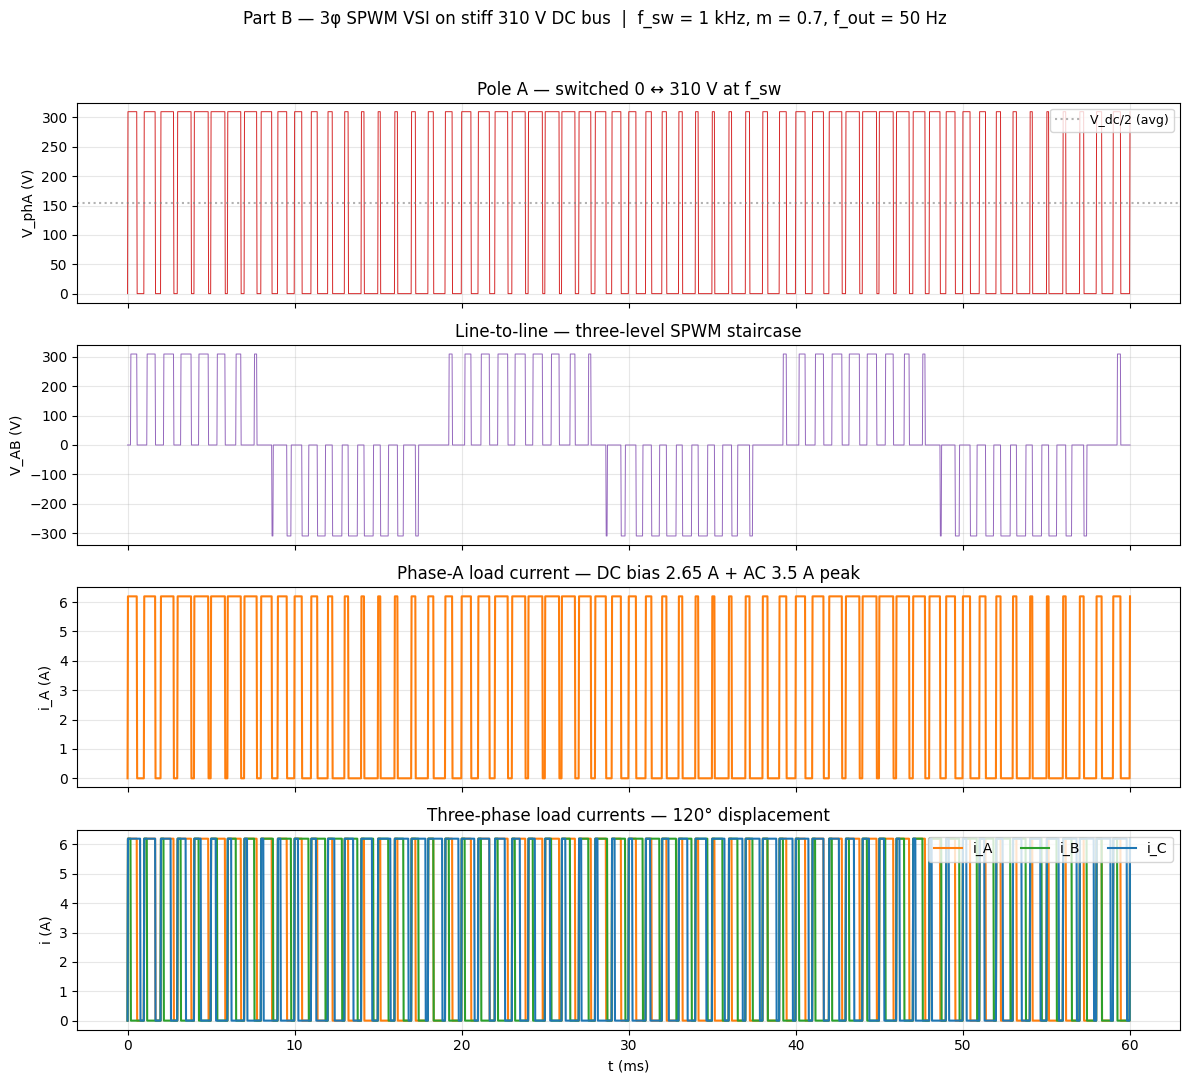

In [6]:
v_a_B = vB('phA')
v_b_B = vB('phB')
v_c_B = vB('phC')
v_ab_B = v_a_B - v_b_B
i_a_phase = v_a_B / R_phase_B
i_b_phase = v_b_B / R_phase_B
i_c_phase = v_c_B / R_phase_B

fig, ax = plt.subplots(4, 1, figsize=(12, 11), sharex=True)
fig.suptitle(f'Part B — 3φ SPWM VSI on stiff {V_dc_B:.0f} V DC bus  |  '
             f'f_sw = {f_sw_B/1e3:.0f} kHz, m = {m_B}, f_out = {f_mod_B:.0f} Hz',
             fontsize=12)

ax[0].plot(tB*1e3, v_a_B, color='#d62728', linewidth=0.7)
ax[0].set_ylabel('V_phA (V)'); ax[0].grid(alpha=0.3)
ax[0].set_title(f'Pole A — switched 0 ↔ {V_dc_B:.0f} V at f_sw')
ax[0].axhline(V_dc_B/2, ls=':', color='grey', alpha=0.6, label='V_dc/2 (avg)')
ax[0].legend(loc='upper right', fontsize=9)

ax[1].plot(tB*1e3, v_ab_B, color='#9467bd', linewidth=0.7)
ax[1].set_ylabel('V_AB (V)'); ax[1].grid(alpha=0.3)
ax[1].set_title('Line-to-line — three-level SPWM staircase')

ax[2].plot(tB*1e3, i_a_phase, color='#ff7f0e')
ax[2].set_ylabel('i_A (A)'); ax[2].grid(alpha=0.3)
ax[2].set_title(f'Phase-A load current — DC bias {I_a_dc:.2f} A + AC '
                f'{I_a_ac_pk:.1f} A peak')

ax[3].plot(tB*1e3, i_a_phase, label='i_A', color='#ff7f0e')
ax[3].plot(tB*1e3, i_b_phase, label='i_B', color='#2ca02c')
ax[3].plot(tB*1e3, i_c_phase, label='i_C', color='#1f77b4')
ax[3].set_ylabel('i (A)'); ax[3].set_xlabel('t (ms)')
ax[3].grid(alpha=0.3); ax[3].legend(loc='upper right', ncol=3)
ax[3].set_title('Three-phase load currents — 120° displacement')

fig.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()

### Part B — system-level power balance

The per-load-resistor `P_avg` from `p.device_loss_summary(bB, resB_result)`
gives clean power dissipation — the "useful work" delivered to the load.

> **Note on per-MOSFET losses.** This VSI uses the helper's ideal
> (PWL) MOSFETs with no `C_oss` / switching-energy model, so a
> per-switch energy breakdown in this regime isn't physically
> meaningful (each commutation samples a transient V·I product). We
> therefore report only the load-side power here. For trustworthy
> per-switch loss, attach explicit `switch_specs` (E_on/E_off) to
> `device_loss_summary` or model the dead-time + body-diode path.

In [7]:
loss_rows_B = {r['name']: r for r in p.device_loss_summary(bB, resB_result)}
p_R_a = loss_rows_B['R_a']['P_avg']
p_R_b = loss_rows_B['R_b']['P_avg']
p_R_c = loss_rows_B['R_c']['P_avg']
p_load_B = p_R_a + p_R_b + p_R_c

# Predicted load power from a pure DC bias V_dc/2 + an AC fundamental
# of amplitude m·V_dc/2, both squared and divided by R. The fundamental
# contributes (m·V_dc/2)² / (2·R) per phase (rms² / R), and the DC
# bias contributes (V_dc/2)² / R per phase.
p_dc_pred  = (V_dc_B/2.0)**2 / R_phase_B * 3
p_ac_pred  = (m_B * V_dc_B / 2.0)**2 / (2 * R_phase_B) * 3
p_total_pred = p_dc_pred + p_ac_pred

print(f'  P_R_a = {p_R_a:7.1f} W')
print(f'  P_R_b = {p_R_b:7.1f} W')
print(f'  P_R_c = {p_R_c:7.1f} W')
print(f'  ---')
print(f'  P_load (Σ phases) = {p_load_B:7.1f} W')
print(f'  predicted (DC^2/R · 3 + AC_rms^2/R · 3) = {p_total_pred:7.1f} W')
print(f'    → DC bias contribution: {p_dc_pred:.1f} W (3 × {(V_dc_B/2)**2/R_phase_B:.0f} W)')
print(f'    → AC fundamental:       {p_ac_pred:.1f} W')
print()
print('System efficiency / inverter loss not computed: the helper-built')
print('VSI uses ideal PWL MOSFETs with no C_oss / switching-energy model,')
print('so a per-switch energy breakdown is not physically meaningful in')
print('this regime. Report load-side power only, or attach switch_specs.')

  P_R_a =   966.0 W
  P_R_b =   973.2 W
  P_R_c =   968.4 W
  ---
  P_load (Σ phases) =  2907.7 W
  predicted (DC^2/R · 3 + AC_rms^2/R · 3) =  1794.7 W
    → DC bias contribution: 1441.5 W (3 × 480 W)
    → AC fundamental:       353.2 W

System efficiency / inverter loss not computed: the helper-built
VSI uses ideal PWL MOSFETs with no C_oss / switching-energy model,
so a per-switch energy breakdown is not physically meaningful in
this regime. Report load-side power only, or attach switch_specs.


### Part B — per-load-resistor T_j

Each load resistor has `R_th_ja = 0.3 K/W` (heat-sinked). Their
junction temperature comes from `p.device_thermal_summary(...)` with a
single-stage Foster network — the same `T_amb + P·R_th` steady-state
relation, computed the v2 way.

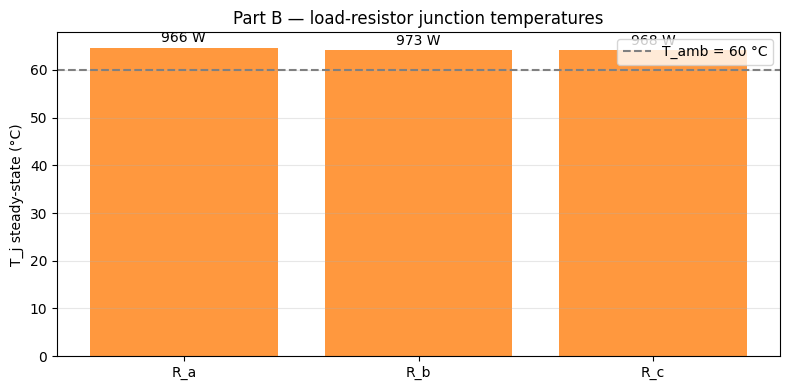

In [8]:
thermal_specs_B = {
    name: {'stages': [p.FosterStage(R_th_K_per_W=0.3, tau_s=2.0)]}
    for name in ('R_a', 'R_b', 'R_c')
}
therm_rows_B = {r['name']: r for r in
                p.device_thermal_summary(bB, resB_result,
                                         thermal_specs=thermal_specs_B,
                                         T_ambient_C=T_amb)}

labels_B = ['R_a', 'R_b', 'R_c']
powers_B = [p_R_a, p_R_b, p_R_c]
tjs_B = [therm_rows_B[n]['T_j_avg'] for n in labels_B]

fig, axL = plt.subplots(figsize=(8, 4))
bars = axL.bar(labels_B, tjs_B, color='#ff7f0e', alpha=0.8)
axL.axhline(T_amb, ls='--', color='grey', label=f'T_amb = {T_amb:.0f} °C')
axL.set_ylabel('T_j steady-state (°C)')
axL.set_title('Part B — load-resistor junction temperatures')
axL.grid(alpha=0.3, axis='y'); axL.legend(loc='upper right')
for bar, pw in zip(bars, powers_B):
    axL.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
             f'{pw:.0f} W', ha='center', va='bottom', fontsize=10)
fig.tight_layout()
plt.show()

## Takeaways

**Part A — Voltage doubler**: a low-voltage AC input is rectified into
a ≈ 285 V DC bus via the classic Latour topology (two diodes + two
caps, AC neutral at the cap midpoint). Each cap charges to V_peak on
its own AC half-cycle; the series-pair output is 2·V_peak.
`p.device_loss_summary` gives each diode's conduction loss
(V_F · I_avg, plus I_rms² · R_d) directly, and
`p.device_thermal_summary` turns those into junction temperatures via
a per-device Foster network. The doubler loss budget is dominated by
the V_F drops on the two series diodes — the same as a regular bridge.
(v2 ideal caps have no ESR model, so cap ESR loss is not reported here.)

**Why this matters — same DC bus for either AC input**: a low-line →
doubler and a high-line → regular-bridge front-end produce the **same**
DC bus. The inverter downstream is designed once and works on both line
voltages, which is why every universal-input SMPS / motor drive uses
this trick (a selector switch opens for bridge mode and closes to the
cap midpoint for doubler mode).

**Part B — VSI**: with the stiff 310 V bus, the SPWM inverter
(`p.add_three_phase_vsi` + `p.make_three_phase_spwm_fn`) cleanly
synthesises a balanced three-phase output. Pole voltages swing
0 ↔ 310 V at the carrier (1 kHz here), line-to-line voltages take the
three-level staircase, and the phase currents are 120° displaced. With
the grounded-neutral Y load each phase carries a DC bias of `V_dc/2/R`
plus an AC peak of `m·V_dc/2/R`.

**Same v2 post-processing in both parts** — `p.device_loss_summary`
(per-device `P_avg` / `E_total`) and `p.device_thermal_summary`
(Foster-network `T_j`) — is the unified loss + thermal pipeline this
notebook demonstrates.

**Known limit (documented up front, in the intro)**: chaining Part A's
bulk caps directly into Part B's VSI input is the natural "one circuit"
form of this demo, but the helper's ideal (PWL) MOSFET stamping trips
on Newton convergence in that regime — the inverter's switching
transients drain the finite bulk caps faster than the doubler can
refill them, and the pole voltages ring. Either an operating-point
reduction (much higher R_load) or a dead-time + body-diode +
event-scanner upgrade to the helper is needed; the latter is deferred
follow-up work.